In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('wine.csv', header=None, usecols=[0, 1, 2])
df.columns = ['Class label', 'Alcohol', 'Malic acid']

In [3]:
df = df.iloc[1:]

In [4]:
df

,Class label,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95
5,1,13.24,2.59
...,...,...,...
174,3,13.71,5.65
175,3,13.4,3.91
176,3,13.27,4.28
177,3,13.17,2.59


In [5]:
df.reset_index(drop=True, inplace=True)

In [6]:
df['Class label'] = pd.to_numeric(df['Class label'], errors='coerce')
df['Alcohol'] = pd.to_numeric(df['Alcohol'], errors='coerce')
df['Malic acid'] = pd.to_numeric(df['Malic acid'], errors='coerce')

<Axes: xlabel='Alcohol', ylabel='Density'>

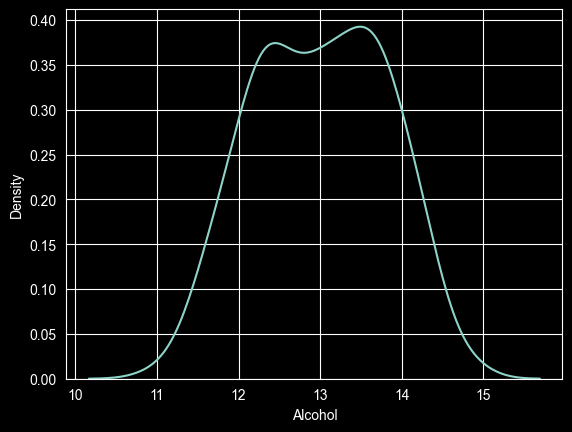

In [7]:
sns.kdeplot(df['Alcohol'], label='Alcohol')

<Axes: xlabel='Malic acid', ylabel='Density'>

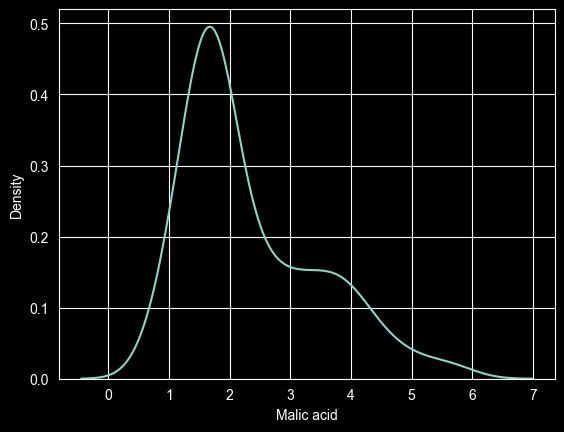

In [8]:
sns.kdeplot(df['Malic acid'], label='Malic acid')

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

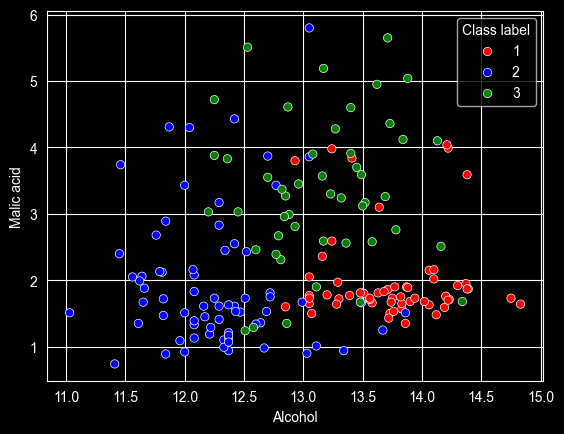

In [9]:
color_dict = {1: 'red', 3: 'green', 2: 'blue'}
sns.scatterplot(x = df['Alcohol'], y = df['Malic acid'], hue = df['Class label'], palette=color_dict)

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Class label', axis=1), df['Class label'], test_size=0.3, random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [13]:
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [14]:
np.round(X_train_scaled.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


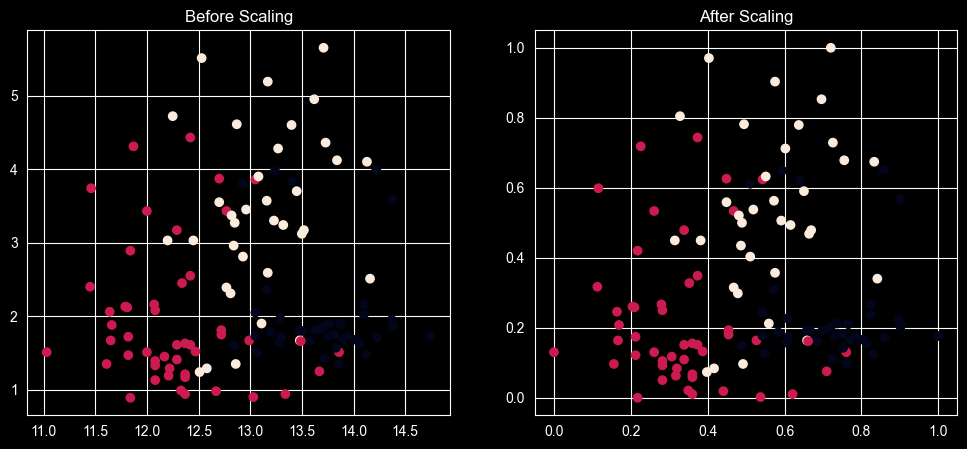

In [16]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c = y_train)
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c = y_train)
ax2.set_title("After Scaling")
plt.show()

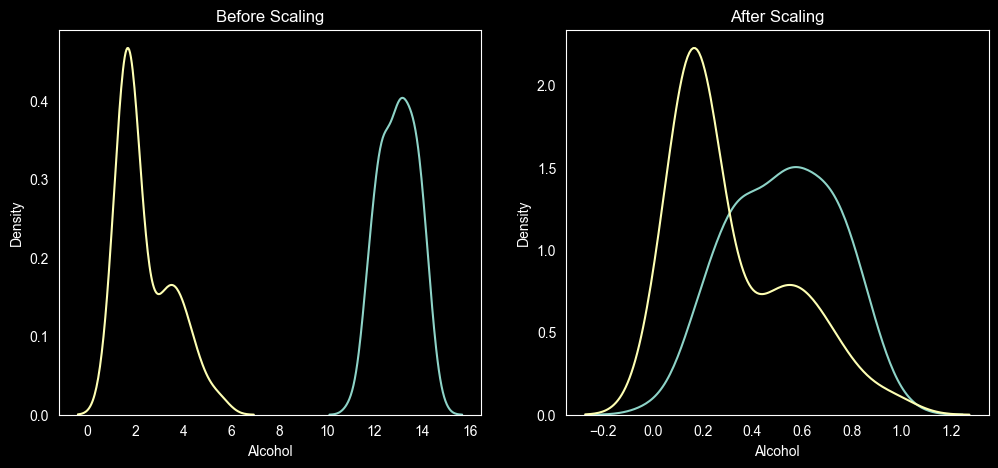

In [20]:
fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

# Before sccaling
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'], label='Alcohol', ax = ax1)
sns.kdeplot(X_train['Malic acid'], label='Malic acid', ax = ax1)
ax1.grid(False)

# After scaling
ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Alcohol'], label='Alcohol', ax = ax2)
sns.kdeplot(X_train_scaled['Malic acid'], label='Malic acid', ax = ax2)
ax2.grid(False)
plt.show()